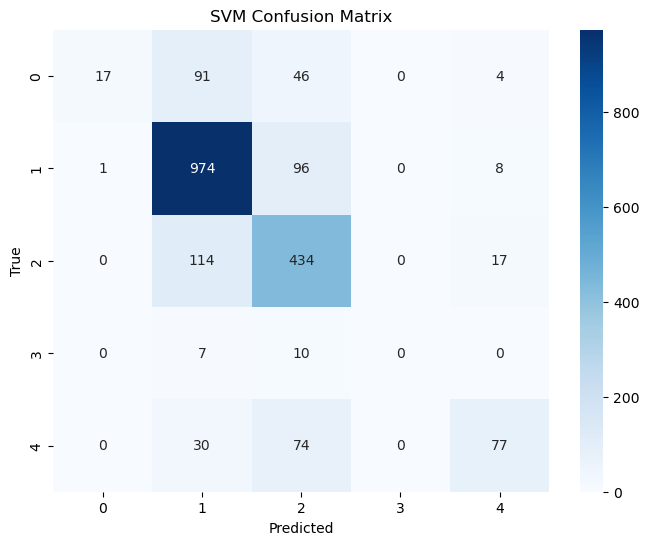

SVM Multiclass AUC Score: 0.8687


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA


X = np.load('X_images.npy')
y = np.load('y_labels.npy')
num_classes = len(np.unique(y))


X_sample, _, y_sample, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=42)


X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)


svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)


y_preds = svm_model.predict(X_test_pca)
y_probs = svm_model.predict_proba(X_test_pca)


cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


y_true_bin = label_binarize(y_test, classes=np.arange(num_classes))
auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
print(f"SVM Multiclass AUC Score: {auc_score:.4f}")